In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency


In [2]:
!apt-get install -y fonts-nanum -q > /dev/null

import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [3]:
df=pd.read_csv('/content/FDA_adverse_events_final.csv')

In [4]:
def U(s):
    return '' if pd.isna(s) else str(s).upper()

def classify_derm(row):
    sd = U(row['suspect_drug']); bn = U(row['brand_name']); t = sd + ' ' + bn
    if 'MINOXIDIL' in t or 'ROGAINE' in t: return 'A. 탈모치료제(Minoxidil)'
    if 'HYDROCORTISONE' in t or 'CORTISOL' in t: return 'B. 스테로이드 항염/항소양크림(Hydrocortisone)'
    if 'TERBINAFINE' in t or 'LAMISIL' in t: return 'C. 항진균제-경구/스프레이(Terbinafine)'
    if 'DOCOSANOL' in t or ('LIDOCAINE' in t and 'GLYCERIN' in t): return 'D. 헤르페스/국소마취(Docosanol+Lidocaine)'
    if 'CLOTRIMAZOLE' in t or 'MICONAZOLE' in t or 'NIZORAL' in t or 'LOTRIMIN' in t: return 'E. 항진균크림(Clotrimazole/Miconazole)'
    if 'TOLNAFTATE' in t: return 'F. 항진균제(Tolnaftate)'
    if 'SALICYLIC ACID' in t: return 'G. 각질제거/사마귀치료(Salicylic Acid)'
    return 'H. 기타'

D = df[df['WHO_ATC']=='D'].copy()
D['category'] = D.apply(classify_derm, axis=1)
H = D[D['category']=='D. 헤르페스/국소마취(Docosanol+Lidocaine)'].copy()

for col in ['serious','is_fatal','is_hospitalized','is_life_threat','is_disabling']:
    v = H[col].astype(str)
    pos = 'Yes' if col=='serious' else 'True'

serious: Abreva=3.7% D=45.6% 전체=85.6%  p(vs D)=0.0000 p(vs 전체)=0.0000
is_fatal: Abreva=0.0% D=3.0% 전체=14.4%  p(vs D)=0.7515 p(vs 전체)=0.0630
is_hospitalized: Abreva=0.0% D=20.6% 전체=34.4%  p(vs D)=0.0170 p(vs 전체)=0.0004
is_life_threat: Abreva=0.0% D=4.1% 전체=5.5%  p(vs D)=0.5758 p(vs 전체)=0.4027
is_disabling: Abreva=0.0% D=3.6% 전체=3.1%  p(vs D)=0.6434 p(vs 전체)=0.7015


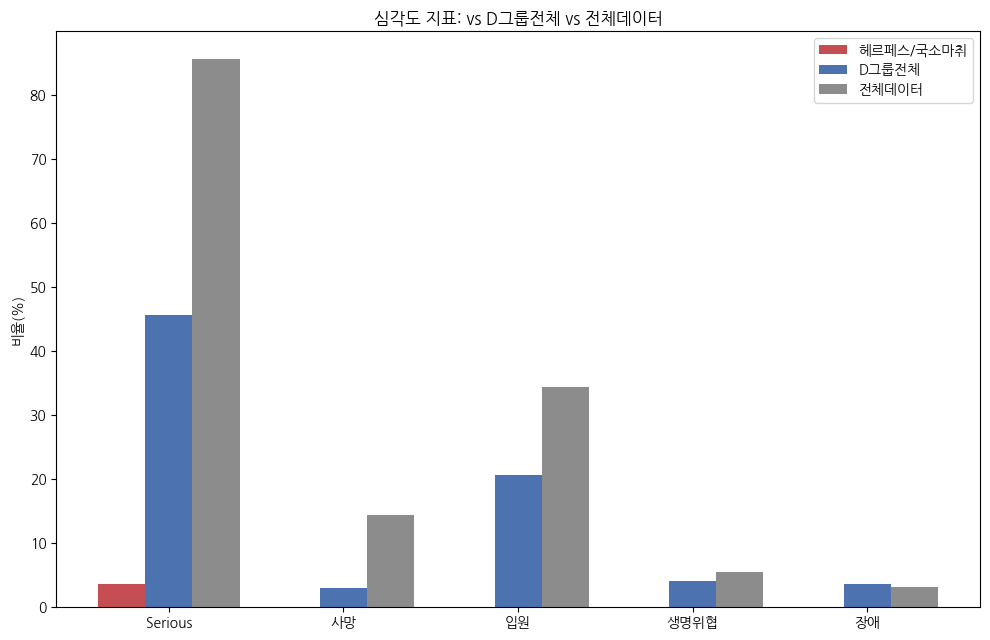

In [5]:
def sev_rate(d, col):
    v = d[col].astype(str)
    pos = 'Yes' if col=='serious' else 'True'
    return round((v==pos).mean()*100,1)

sev_cols = ['serious','is_fatal','is_hospitalized','is_life_threat','is_disabling']
sev_labels = ['Serious','사망','입원','생명위협','장애']

abreva_rates, d_rates, all_rates, p_vs_d, p_vs_all = [], [], [], [], []
for col in sev_cols:
    h_r, d_r, a_r = sev_rate(H,col), sev_rate(D,col), sev_rate(df,col)
    abreva_rates.append(h_r); d_rates.append(d_r); all_rates.append(a_r)
    v_h=H[col].astype(str); v_d=D[col].astype(str); v_all=df[col].astype(str)
    pos='Yes' if col=='serious' else 'True'; neg='No' if col=='serious' else 'False'
    _,pd_,_,_ = chi2_contingency([[(v_h==pos).sum(),(v_h==neg).sum()],[(v_d==pos).sum(),(v_d==neg).sum()]])
    _,pa_,_,_ = chi2_contingency([[(v_h==pos).sum(),(v_h==neg).sum()],[(v_all==pos).sum(),(v_all==neg).sum()]])
    p_vs_d.append(pd_); p_vs_all.append(pa_)
    print(f'{col}: Abreva={h_r}% D={d_r}% 전체={a_r}%  p(vs D)={pd_:.4f} p(vs 전체)={pa_:.4f}')

plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 6.5))
x = range(len(sev_labels)); w=0.27
ax.bar([i-w for i in x], abreva_rates, width=w, label=f'헤르페스/국소마취', color='#C44E52')
ax.bar([i for i in x], d_rates, width=w, label='D그룹전체', color='#4C72B0')
ax.bar([i+w for i in x], all_rates, width=w, label='전체데이터', color='#8C8C8C')
ax.set_xticks(x); ax.set_xticklabels(sev_labels)
ax.set_ylabel('비율(%)')
ax.set_title('심각도 지표: vs D그룹전체 vs 전체데이터')
ax.legend()
plt.tight_layout()
plt.show()

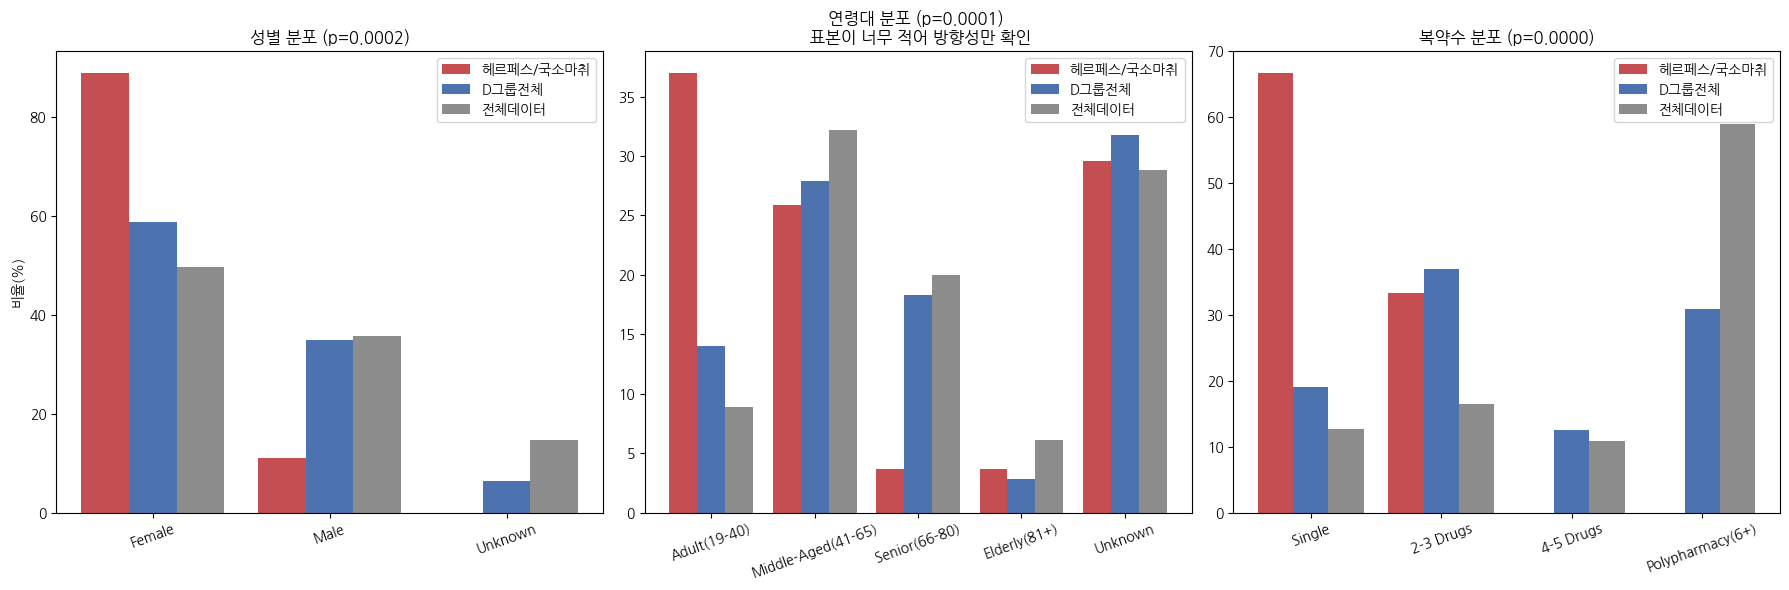

In [6]:
def dist_table(d, col, label):
    cnt = d[col].value_counts()
    pct = (cnt / len(d) * 100).round(1)
    return pd.DataFrame({f'{label}_건수': cnt, f'{label}_비율(%)': pct})

# 성별
sex_h = dist_table(H, 'patient_sex', 'Abreva')
sex_d = dist_table(D, 'patient_sex', 'D그룹전체')
sex_all = dist_table(df, 'patient_sex', '전체데이터')
sex_compare = sex_h.join(sex_d, how='outer').join(sex_all, how='outer').fillna(0)

tab_sex_vs_all = pd.crosstab(pd.concat([H['patient_sex'], df['patient_sex']]), ['H']*len(H)+['전체']*len(df))
_, p_sex_all, _, _ = chi2_contingency(tab_sex_vs_all)

# 연령대 (Unknown 제외 검정)
age_order = ['Adult(19-40)','Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)','Unknown']
age_h = dist_table(H, 'age_group', 'Abreva')
age_d = dist_table(D, 'age_group', 'D그룹전체')
age_all = dist_table(df, 'age_group', '전체데이터')
age_compare = age_h.join(age_d, how='outer').join(age_all, how='outer').fillna(0).reindex(age_order).fillna(0)

H_age = H[H['age_group'] != 'Unknown']
df_age = df[df['age_group'] != 'Unknown']
tab_age_vs_all = pd.crosstab(pd.concat([H_age['age_group'], df_age['age_group']]), ['H']*len(H_age)+['전체']*len(df_age))
_, p_age_all, _, _ = chi2_contingency(tab_age_vs_all)

# 복약수
dc_order = ['Single','2-3 Drugs','4-5 Drugs','Polypharmacy(6+)']
dc_h = dist_table(H, 'drug_count_category', 'Abreva')
dc_d = dist_table(D, 'drug_count_category', 'D그룹전체')
dc_all = dist_table(df, 'drug_count_category', '전체데이터')
dc_compare = dc_h.join(dc_d, how='outer').join(dc_all, how='outer').fillna(0).reindex(dc_order).fillna(0)

tab_dc_vs_all = pd.crosstab(pd.concat([H['drug_count_category'], df['drug_count_category']]), ['H']*len(H)+['전체']*len(df))
_, p_dc_all, _, _ = chi2_contingency(tab_dc_vs_all)


# 시각화
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
w = 0.27

def plot3(ax, compare_df, title):
    x = range(len(compare_df))
    ax.bar([i-w for i in x], compare_df['Abreva_비율(%)'], width=w, label='헤르페스/국소마취', color='#C44E52')
    ax.bar([i for i in x], compare_df['D그룹전체_비율(%)'], width=w, label='D그룹전체', color='#4C72B0')
    ax.bar([i+w for i in x], compare_df['전체데이터_비율(%)'], width=w, label='전체데이터', color='#8C8C8C')
    ax.set_xticks(x); ax.set_xticklabels(compare_df.index, rotation=20)
    ax.set_title(title)
    ax.legend()

plot3(axes[0], sex_compare, f'성별 분포 (p={p_sex_all:.4f})')
axes[0].set_ylabel('비율(%)')
plot3(axes[1], age_compare, f'연령대 분포 (p={p_age_all:.4f}) \n 표본이 너무 적어 방향성만 확인')
plot3(axes[2], dc_compare, f'복약수 분포 (p={p_dc_all:.4f})')
plt.tight_layout()
plt.show()

chi2=3117.22, p=0.0000e+00


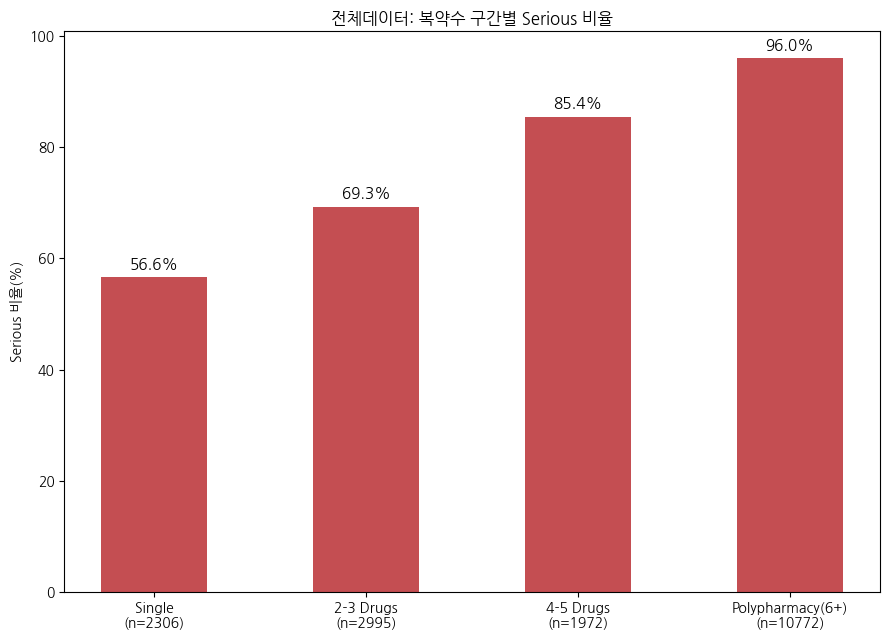

In [7]:
dc_order = ['Single','2-3 Drugs','4-5 Drugs','Polypharmacy(6+)']
serious_by_dc = df.groupby('drug_count_category')['serious'].apply(lambda x: (x=='Yes').mean()*100)
serious_by_dc = serious_by_dc.reindex(dc_order)
n_by_dc = df['drug_count_category'].value_counts().reindex(dc_order)

tab = pd.crosstab(df['drug_count_category'], df['serious']).reindex(dc_order)
chi2, p, dof, exp = chi2_contingency(tab)
print(f'chi2={chi2:.2f}, p={p:.4e}')

plt.rcParams['axes.unicode_minus'] = False

labels = [f'{dc}\n(n={n})' for dc, n in zip(dc_order, n_by_dc)]
fig, ax = plt.subplots(figsize=(9, 6.5))
bars = ax.bar(labels, serious_by_dc.values, color='#C44E52', width=0.5)
for bar, v in zip(bars, serious_by_dc.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+1.5, f'{v:.1f}%', ha='center', fontsize=11)
ax.set_ylabel('Serious 비율(%)')
ax.set_title('전체데이터: 복약수 구간별 Serious 비율')
plt.tight_layout()

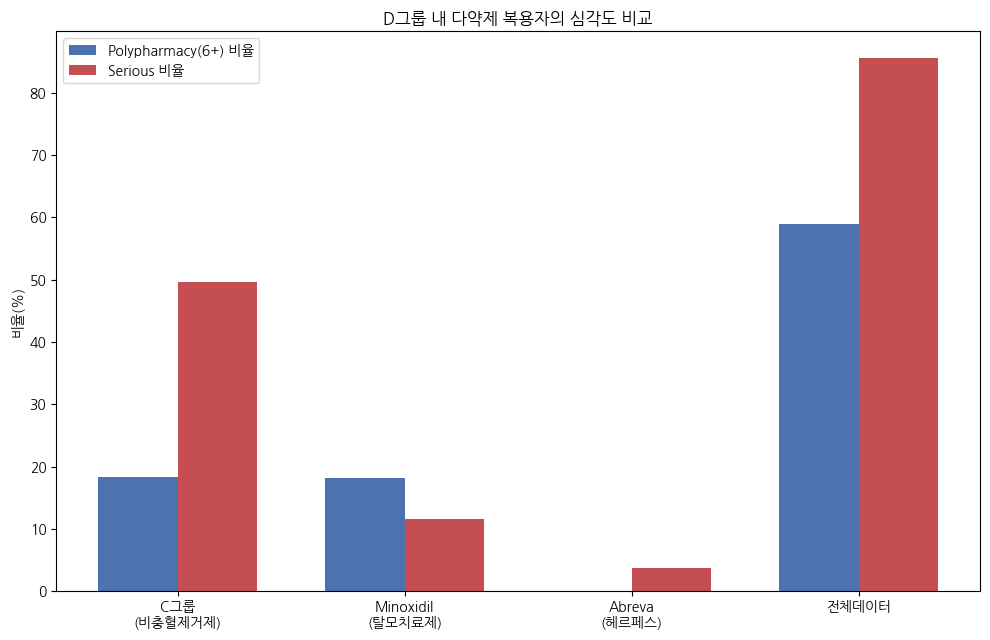

In [8]:
groups = ['C그룹\n(비충혈제거제)','Minoxidil\n(탈모치료제)','Abreva\n(헤르페스)','전체데이터']
poly = [18.3, 18.2, 0.0, 59.0]
serious = [49.6, 11.6, 3.7, 85.6]

fig, ax1 = plt.subplots(figsize=(10, 6.5))
x = range(len(groups)); w = 0.35
b1 = ax1.bar([i-w/2 for i in x], poly, width=w, label='Polypharmacy(6+) 비율', color='#4C72B0')
b2 = ax1.bar([i+w/2 for i in x], serious, width=w, label='Serious 비율', color='#C44E52')
ax1.set_xticks(x); ax1.set_xticklabels(groups)
ax1.set_ylabel('비율(%)')
ax1.set_title('D그룹 내 다약제 복용자의 심각도 비교')
ax1.legend()
plt.tight_layout()
plt.show()

reaction_cat
오남용/사용행태(용법·품질·포장)       16
국소반응(도포부위)                5
기타                        4
전신/신경계 의심(리도카인 흡수 추정)     2
Name: count, dtype: int64


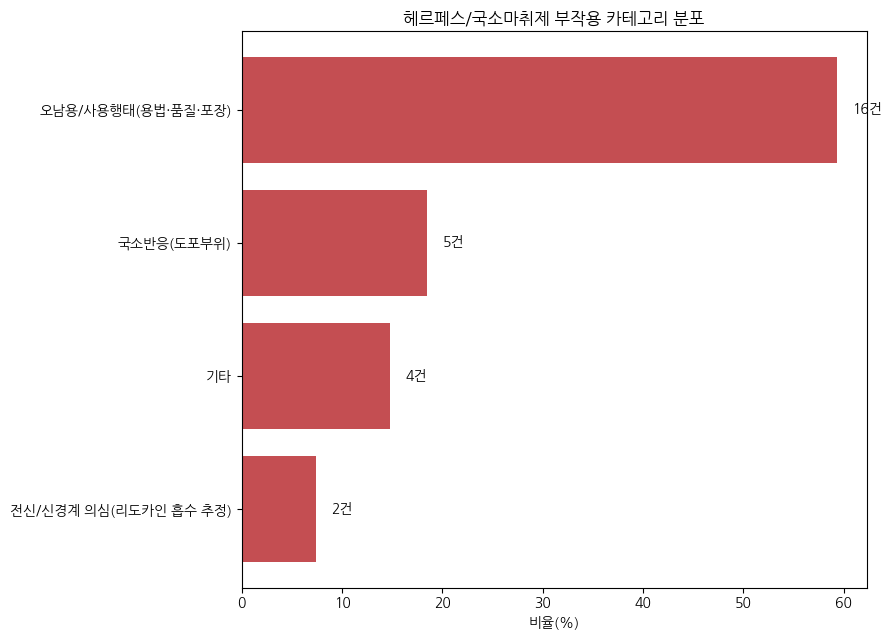

In [9]:
def reaction_category(reaction):
    t = str(reaction).upper()
    misuse_kw = ['ADMINISTRATION ERROR','INCORRECT','INAPPROPRIATE SCHEDULE','PRODUCT QUALITY',
                 'PRODUCT PACKAGE','PACKAGING','PRODUCT COMPLAINT']
    site_kw = ['APPLICATION SITE','BLISTER']
    systemic_kw = ['FEELING DRUNK','PARAESTHESIA']
    if any(k in t for k in misuse_kw): return '오남용/사용행태(용법·품질·포장)'
    if any(k in t for k in site_kw): return '국소반응(도포부위)'
    if any(k in t for k in systemic_kw): return '전신/신경계 의심(리도카인 흡수 추정)'
    return '기타'

H['reaction_cat'] = H['primary_reaction'].apply(reaction_category)
cat_counts = H['reaction_cat'].value_counts()
print(cat_counts)

plt.rcParams['axes.unicode_minus'] = False

pct = (cat_counts / len(H) * 100).round(1)
fig, ax = plt.subplots(figsize=(9, 6.5))
bars = ax.barh(cat_counts.index[::-1], pct.values[::-1], color='#C44E52')
for bar, c in zip(bars, cat_counts.values[::-1]):
    ax.text(bar.get_width()+1.5, bar.get_y()+bar.get_height()/2, f'{c}건', va='center', fontsize=10)
ax.set_xlabel('비율(%)')
ax.set_title(f'헤르페스/국소마취제 부작용 카테고리 분포')
plt.tight_layout()
plt.show()

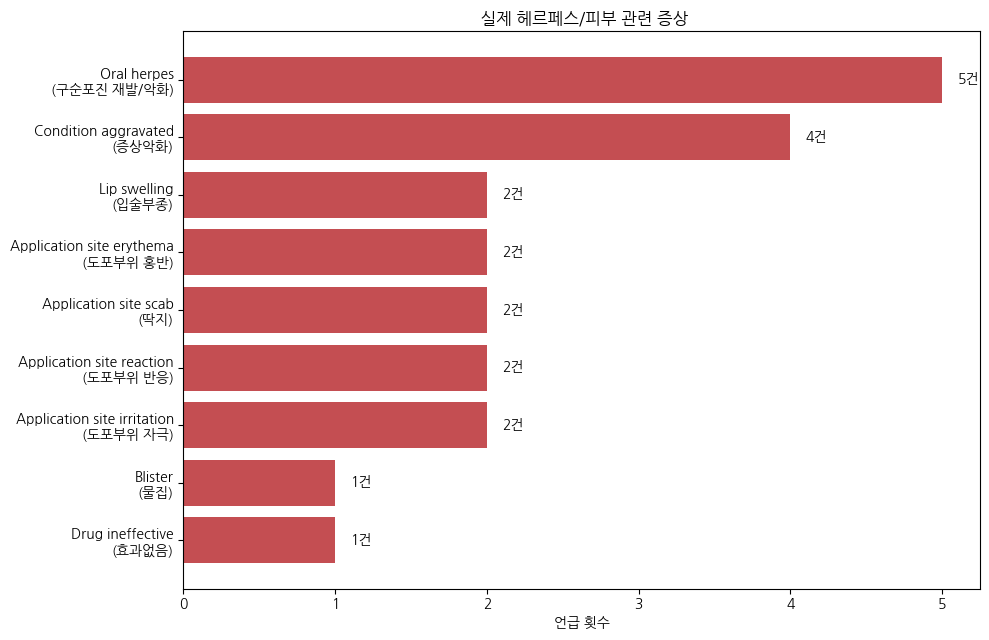

In [10]:
all_symptoms = []
for r in H['reactions'].dropna():
    parts = [p.strip() for p in r.split(';')]
    all_symptoms.extend(parts)
plt.rcParams['axes.unicode_minus'] = False

# 라벨을 "영어\n(한글)" 형태로 딕셔너리에 정의
disease_symptoms = {
    'Oral herpes\n(구순포진 재발/악화)': 5,
    'Condition aggravated\n(증상악화)': 4,
    'Lip swelling\n(입술부종)': 2,
    'Application site erythema\n(도포부위 홍반)': 2,
    'Application site scab\n(딱지)': 2,
    'Application site reaction\n(도포부위 반응)': 2,
    'Application site irritation\n(도포부위 자극)': 2,
    'Blister\n(물집)': 1,
    'Drug ineffective\n(효과없음)': 1,
}

fig, ax = plt.subplots(figsize=(10, 6.5))
labels = list(disease_symptoms.keys())[::-1]
values = list(disease_symptoms.values())[::-1]
bars = ax.barh(labels, values, color='#C44E52')
for bar, c in zip(bars, values):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2, f'{c}건', va='center', fontsize=10)
ax.set_xlabel('언급 횟수')
ax.set_title(' 실제 헤르페스/피부 관련 증상')
plt.tight_layout()
plt.show()